# Visualizing and Exploring Exoplanet Data
Performing exploratory data analysis on NASA's Exoplanet archive CSV.
## Questions asked
1. How have discoveries grown over time?
2. Which discovery method dominates?
3. What sizes are most common?
4. Do hotter stars have shorter-period planets?
5. Where are planets found?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
print("setup complete")

setup complete


In [4]:
planets=pd.read_csv("C:/Users/Rohan/Desktop/dspro/planetsEDA/dataset/PSCompPars.csv", comment="#")
planets.head()

,pl_name,hostname,sy_snum,sy_pnum,discoverymethod,disc_year,disc_facility,pl_controv_flag,pl_orbper,pl_orbpererr1,...,sy_disterr2,sy_vmag,sy_vmagerr1,sy_vmagerr2,sy_kmag,sy_kmagerr1,sy_kmagerr2,sy_gaiamag,sy_gaiamagerr1,sy_gaiamagerr2
0,11 Com b,11 Com,2,1,Radial Velocity,2007.0,Xinglong Station,0,323.21000,0.06,...,-1.9238,4.72307,0.023,-0.023,2.282,0.346,-0.346,4.44038,0.003848,-0.003848
1,11 UMi b,11 UMi,1,1,Radial Velocity,2009.0,Thueringer Landessternwarte Tautenburg,0,516.21997,3.20,...,-1.9765,5.01300,0.005,-0.005,1.939,0.270,-0.270,4.56216,0.003903,-0.003903
2,14 And b,14 And,1,1,Radial Velocity,2008.0,Okayama Astrophysical Observatory,0,186.76000,0.11,...,-0.7140,5.23133,0.023,-0.023,2.331,0.240,-0.240,4.91781,0.002826,-0.002826
3,14 Her b,14 Her,1,2,Radial Velocity,2002.0,W. M. Keck Observatory,0,1766.41000,0.67,...,-0.0073,6.61935,0.023,-0.023,4.714,0.016,-0.016,6.38300,0.000351,-0.000351
4,16 Cyg B b,16 Cyg B,3,1,Radial Velocity,1996.0,Multiple Observatories,0,798.50000,1.00,...,-0.0111,6.21500,0.016,-0.016,4.651,0.016,-0.016,6.06428,0.000603,-0.000603


In [9]:
planets.shape

(6298, 84)

In [6]:
cols = ['pl_name','disc_year','discoverymethod','pl_rade','pl_bmasse',
        'pl_orbper','pl_eqt','st_teff','st_rad','st_mass','sy_dist','sy_snum']
planets=planets[cols]
planets.head()

,pl_name,disc_year,discoverymethod,pl_rade,pl_bmasse,pl_orbper,pl_eqt,st_teff,st_rad,st_mass,sy_dist,sy_snum
0,11 Com b,2007.0,Radial Velocity,12.2,4914.898486,323.21000,NaN,4874.0,13.76,2.09,93.1846,2
1,11 UMi b,2009.0,Radial Velocity,12.3,4684.814200,516.21997,NaN,4213.0,29.79,2.78,125.3210,1
2,14 And b,2008.0,Radial Velocity,13.1,1131.151301,186.76000,NaN,4888.0,11.55,1.78,75.4392,1
3,14 Her b,2002.0,Radial Velocity,12.5,2828.672822,1766.41000,NaN,5338.0,0.93,0.97,17.9323,1
4,16 Cyg B b,1996.0,Radial Velocity,13.5,565.737400,798.50000,NaN,5750.0,1.13,1.08,21.1397,3


# Data Cleaning
### 1. Detecting null values.

In [15]:
planets.isnull().sum()

pl_name               0
disc_year             1
discoverymethod       0
pl_rade              50
pl_bmasse            31
pl_orbper           340
pl_eqt             1605
st_teff             294
st_rad              318
st_mass               9
sy_dist              27
sy_snum               0
dtype: int64

In [17]:
radius_data = planets.dropna(subset=['pl_rade'])
distance_data = planets.dropna(subset=['sy_dist'])

Missing values were present in several numerical columns. Since the analysis focused on planet radius, discovery year, discovery method, and distance, missing values were handled on a per-analysis basis using dropna() rather than imputing values globally.

## Exploratory Data Analysis
### 1. How have discoveries grown over time?

<Axes: title={'center': 'Growth in discovery over the years'}, xlabel='disc_year', ylabel='count'>

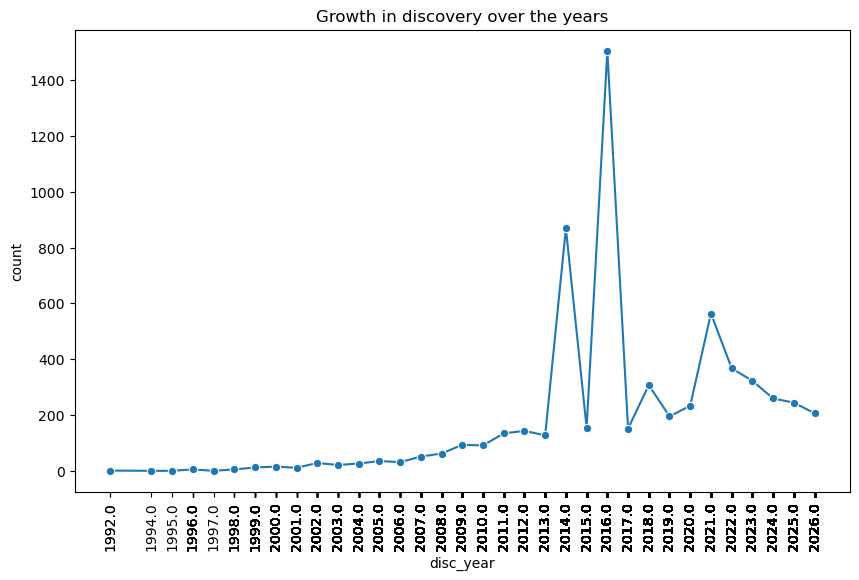

In [13]:
discovery=planets.groupby("disc_year").size().reset_index()
discovery=discovery.rename(columns={0:"count"})
plt.figure(figsize=(10,6))
plt.xticks(ticks=planets.disc_year, labels=planets.disc_year, rotation=90)
plt.title("Growth in discovery over the years")
sns.lineplot(
    data=discovery,
    x='disc_year',
    y='count',
    marker='o'
)

Number of planets discovered peaked during 2014 to 2021 preceded by technological advancements. After 2021, there has been a constant decline in the number of planets detected. Indicating possible state of saturation with current technology level.

### 2. Which discovery method dominates?

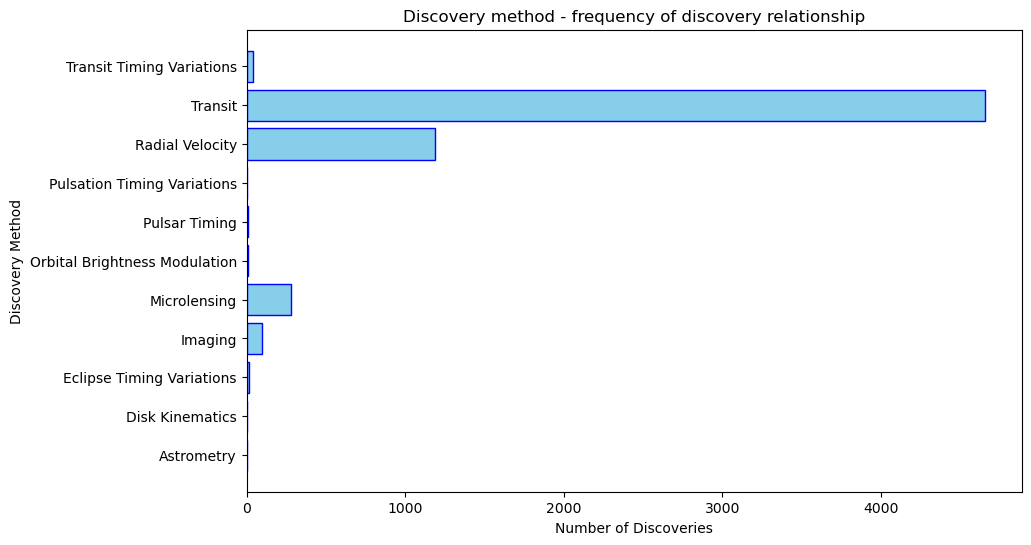

,discoverymethod,discoverycount
0,Astrometry,6
1,Disk Kinematics,1
2,Eclipse Timing Variations,17
3,Imaging,97
4,Microlensing,278
5,Orbital Brightness Modulation,9
6,Pulsar Timing,8
7,Pulsation Timing Variations,2
8,Radial Velocity,1186
9,Transit,4653


In [109]:
method=planets.groupby("discoverymethod").size().reset_index()
method=method.rename(columns={0:"discoverycount"})
plt.figure(figsize=(10,6))
plt.barh(method.discoverymethod, method.discoverycount, color="skyblue", edgecolor="blue")
plt.xlabel("Number of Discoveries")
plt.ylabel("Discovery Method")
plt.title("Discovery method - frequency of discovery relationship")
plt.show()
method

Transit discovery method by far exceeds other methods, with total of 4653 discoveries made. Radial velocity comes second with 1186 planets discovered till date.

### 3. What sizes are most common?
Of all ~6200 planets, how many are tiny like Earth, how many are medium, and how many are large like Jupiter

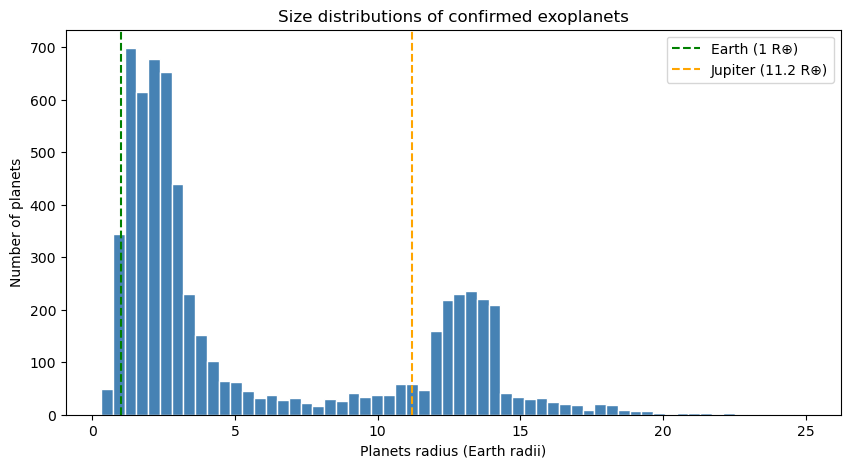

In [107]:
#cleaning data
planet_radius=planets.dropna(subset=['pl_rade'])
pla_small=planet_radius[planet_radius.pl_rade<=25]

fig, ax= plt.subplots(figsize=(10, 5))
ax.hist(pla_small['pl_rade'], bins=60, color='steelblue', edgecolor='white')

#verticle reference lines for earth amd jupiter
ax.axvline(x=1, color='green', linestyle='--', label='Earth (1 R⊕)')
ax.axvline(x=11.2, color='orange', linestyle='--', label='Jupiter (11.2 R⊕)')

ax.set_xlabel('Planets radius (Earth radii)')
ax.set_ylabel('Number of planets')
ax.set_title('Size distributions of confirmed exoplanets')
ax.legend()
plt.show()

The histogram reveals a strong peal around 2-3 Earth radii, a category called 'sub-Neptunes'. This is partly due to a detection bias. Transit surveys like Kepler are better at finding larger planets close to their stars.

### 4. Do hotter stars have shorted-period planets?
Using stellar effective temperature(K) and planet orbit period.

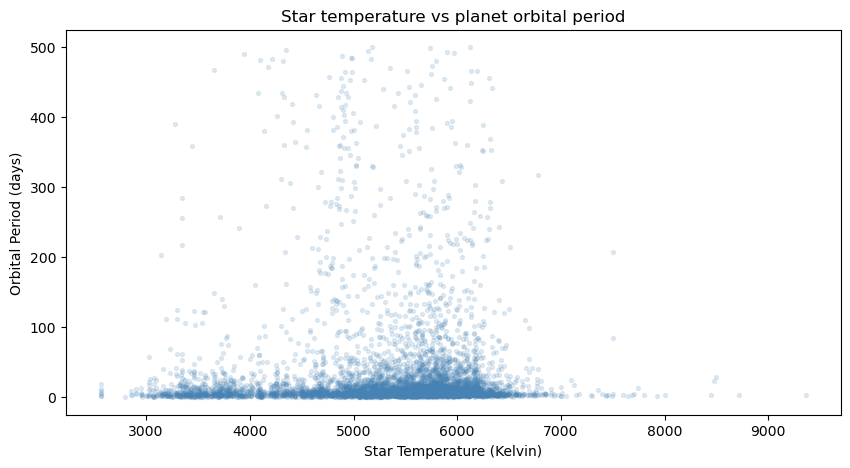

In [105]:
temp_orbit=planets.dropna(subset=['st_teff', 'pl_orbper'])

#defining a reasonable range
temp_orbit=temp_orbit[
(temp_orbit['st_teff']>2000) & (temp_orbit['st_teff']<10000) & (temp_orbit['pl_orbper']<500)
]

fig, ax=plt.subplots(figsize=(10, 5))

ax.scatter(
    temp_orbit['st_teff'],
    temp_orbit['pl_orbper'],
    alpha=0.15, #transparency
    s=8, #dot size
    color='steelblue'
)

ax.set_xlabel("Star Temperature (Kelvin)")
ax.set_ylabel("Orbital Period (days)")
ax.set_title("Star temperature vs planet orbital period")
plt.show()

Most planets cluster below 100-day orbits regardless of star temperature. These are hot Jupiters and sub-Neptunes that are easiest to detect. The spare upper region represents long-period planets that are harder to confirm and requires years of observation.

### 5. Where are planets found?
Are confirmed planets nearby, or spread far across the galaxy?
Using log scale on x-axis, because in a distance span from 4 to 30,000 parsecs a normal axis would crush most data into one corner. 

In [90]:
pla_dist=planets.dropna(subset=['sy_dist']).copy()
print(pla_dist['sy_dist'].describe())
pla_dist['dist_ly']=pla_dist['sy_dist']*3.26

count    6271.000000
mean      703.341417
std      1210.126435
min         1.301190
25%       101.632000
50%       361.896000
75%       824.499000
max      8500.000000
Name: sy_dist, dtype: float64


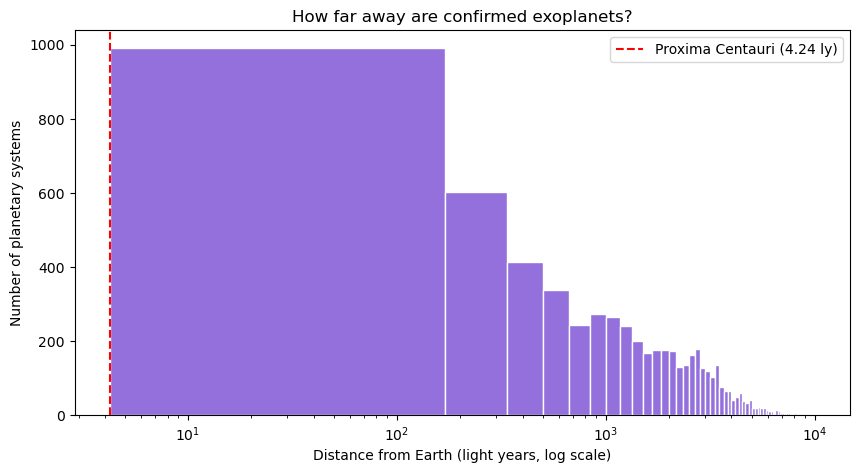

In [103]:
fig, ax=plt.subplots(figsize=(10, 5))
ax.hist(pla_dist['dist_ly'], bins=60, range=(pla_dist['dist_ly'].min(), 10000), color='mediumpurple', edgecolor='white')
#log scale
ax.set_xscale('log')
ax.axvline(x=4.24, color='red', linestyle='--', label='Proxima Centauri (4.24 ly)')
ax.set_xlabel('Distance from Earth (light years, log scale)')
ax.set_ylabel('Number of planetary systems')
ax.set_title('How far away are confirmed exoplanets?')
ax.legend()
plt.show()

Insight:
1. The firt bar corresponds to planets discovered via ground-based surveys and the TESS mission. TESS was designed to find planets closer to the Earth so that we could study their atmosphere later.
2. The second prominent bar is due to the Kepler mission. Kepler stared at one fixed patch of sky for 9 years and found thousands of planets at that specific depth.
3. The gap in between is where niether TESS nor Kepler focuses.